# 01 — Signal exploration on a single participant

This notebook is a **visual verification step** before running the full batch pipeline.
Its purpose is to:
1. Check that the preprocessing pipeline (filtering, normalization) works as expected
2. Visually inspect the detected extrema on each signal
3. Verify that the computed metrics make intuitive sense

Run this notebook on at least one SZ and one P participant before running `02_batch.ipynb`.

## 0. Imports and configuration

In [1]:
import sys
import os

# Make sure the project root is in the Python path
# (required when running notebooks from the notebooks/ subfolder)
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sources.config import ALL_SIGNAL_NAMES, FS
from sources.preprocessing import (
    parse_participant_info,
    build_wide_df,
    build_signals,
    normalize_signals,
    preprocess_signals,
)
from sources.metrics import (
    get_local_extrema,
    compute_extrema_metrics,
    motion_sum_for_marker,
)

print("Imports OK")

Imports OK


## 1. Load one participant

Change `FILEPATH` to inspect a different participant.

In [2]:
FILEPATH = os.path.join(ROOT, "data", "SZ", "landmarks_SZ1_POSE.csv")

info = parse_participant_info(FILEPATH)
print(f"Participant : {info['participant_id']}  |  Group : {info['group']}")

df_raw = pd.read_csv(FILEPATH)
print(f"Raw CSV shape : {df_raw.shape}")
df_raw.head()

Participant : SZ1  |  Group : SZ
Raw CSV shape : (26934, 6)


,frame,type,index,x,y,z
0,0,pose,0,0.509079,0.153492,-0.239518
1,0,pose,1,0.511716,0.136946,-0.222692
2,0,pose,2,0.514871,0.136040,-0.222996
3,0,pose,3,0.518125,0.135280,-0.222898
4,0,pose,4,0.502163,0.138803,-0.222965


## 2. Build wide DataFrame and check derived points

In [3]:
df_w = build_wide_df(df_raw)
print(f"Wide DataFrame shape : {df_w.shape}")
print(f"Number of frames     : {len(df_w)}")
print(f"Duration             : {len(df_w) / FS:.1f} seconds")

# Check that derived columns were created
derived_cols = ["mid_shoulders_x", "mid_hips_x", "torso_center_x"]
for col in derived_cols:
    status = "OK" if col in df_w.columns else "MISSING"
    print(f"  {col:25s} : {status}")

Wide DataFrame shape : (923, 102)
Number of frames     : 923
Duration             : 30.8 seconds
  mid_shoulders_x           : OK
  mid_hips_x                : OK
  torso_center_x            : OK


## 3. Build and preprocess signals

In [4]:
signals_raw  = build_signals(df_w)
signals_norm = normalize_signals(signals_raw, df_w)
signals_f    = preprocess_signals(signals_norm)

# Report available vs missing signals
print(f"Signals available ({len(signals_f)}/{len(ALL_SIGNAL_NAMES)}):")
for name in ALL_SIGNAL_NAMES:
    status = "OK" if name in signals_f else "MISSING (landmark absent)"
    print(f"  {name:30s} : {status}")

Signals available (10/10):
  left_hand_vertical             : OK
  right_hand_vertical            : OK
  left_hand_horizontal           : OK
  right_hand_horizontal          : OK
  swaying                        : OK
  sideways                       : OK
  head_horizontal                : OK
  head_vertical                  : OK
  left_foot_horizontal           : OK
  right_foot_horizontal          : OK


## 4. Visual check: raw vs filtered signals

Each subplot shows the raw signal (faded) and the filtered + centered signal (solid).
The filter should remove high-frequency noise while preserving the main movement pattern.

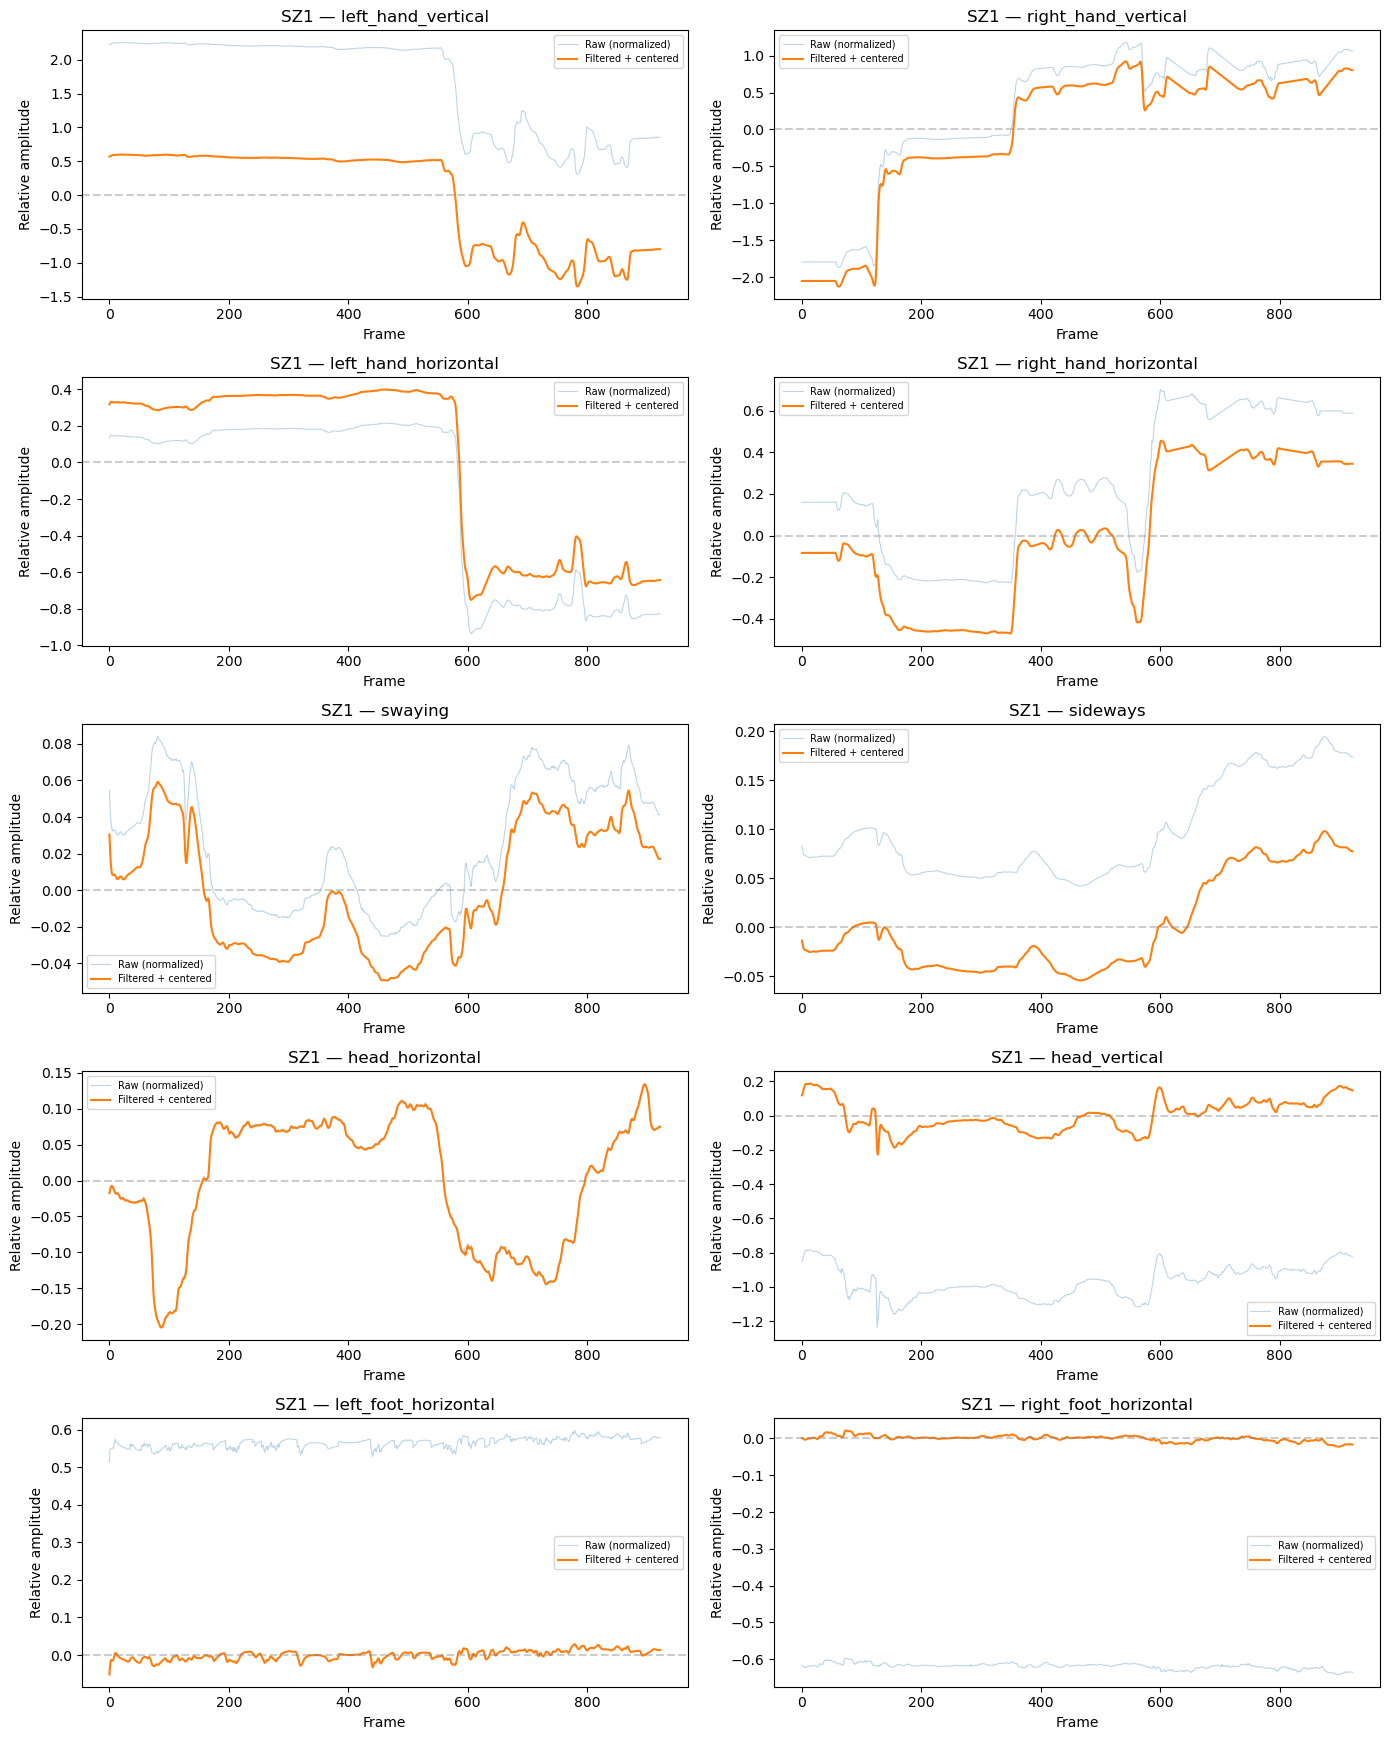

Figure saved to results/


In [5]:
frames = df_w["frame"].to_numpy()
n = len(signals_f)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.ravel()

for ax, name in zip(axes, signals_f.keys()):
    raw = np.asarray(signals_norm[name].interpolate().bfill().ffill(), dtype=float)
    filt = np.asarray(signals_f[name], dtype=float)

    ax.plot(frames, raw,  alpha=0.3, linewidth=0.8, label="Raw (normalized)")
    ax.plot(frames, filt, linewidth=1.5, label="Filtered + centered")
    ax.axhline(0, linestyle="--", alpha=0.4, color="gray")
    ax.set_title(f"{info['participant_id']} — {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Relative amplitude")
    ax.legend(fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "results", f"{info['participant_id']}_signals.png"),
            dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to results/")

## 5. Visual check: extrema detection

Triangles show detected local maxima (▲) and minima (▽) on the filtered signal.
Check that extrema correspond to actual turning points of the movement.

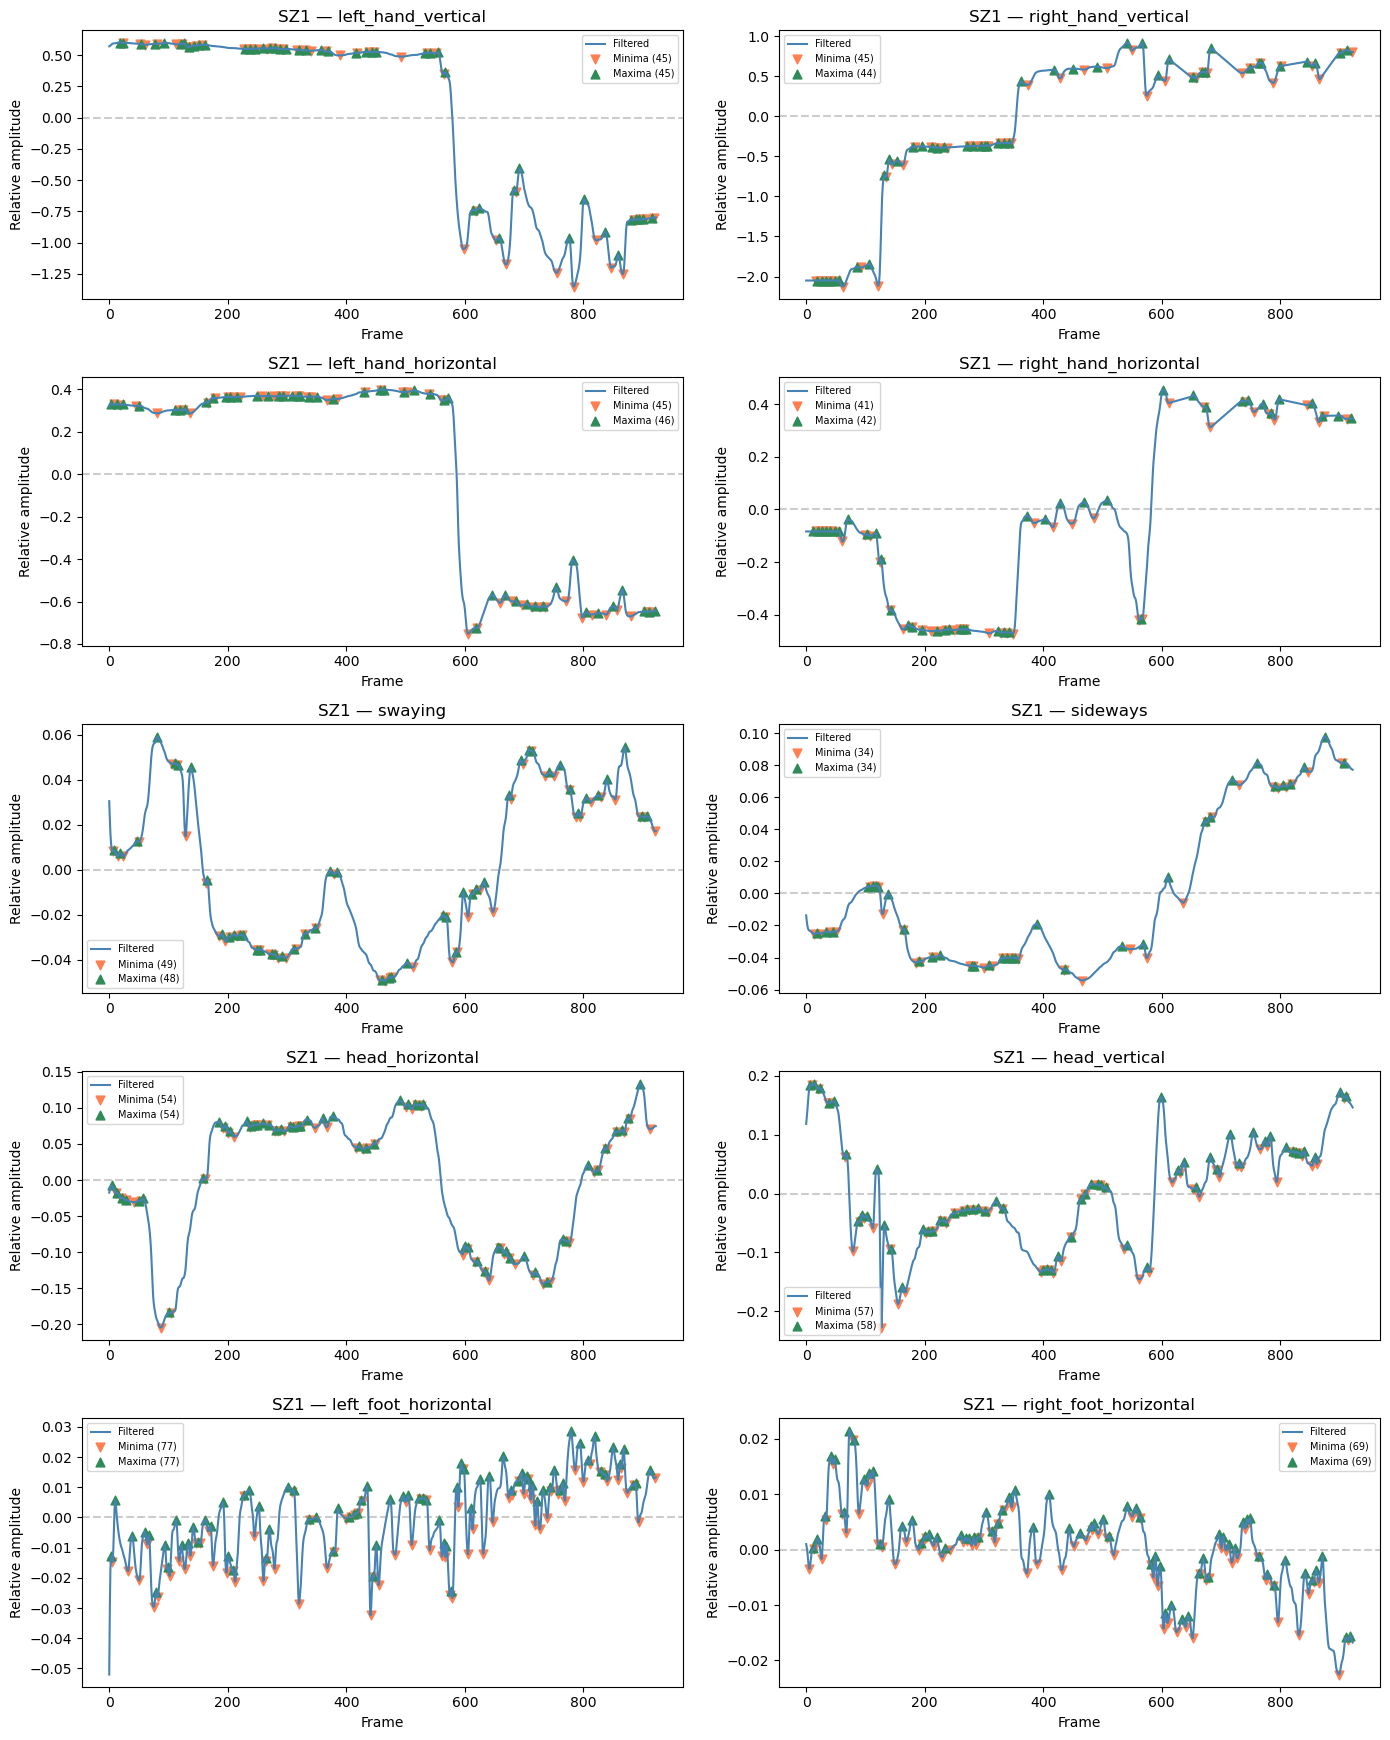

Figure saved to results/


In [6]:
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes = axes.ravel()

for ax, name in zip(axes, signals_f.keys()):
    filt = np.asarray(signals_f[name], dtype=float)
    min_idx, max_idx = get_local_extrema(filt)

    ax.plot(frames, filt, linewidth=1.5, color="steelblue", label="Filtered")
    ax.scatter(frames[min_idx], filt[min_idx],
               marker="v", s=40, color="coral",  label=f"Minima ({len(min_idx)})")
    ax.scatter(frames[max_idx], filt[max_idx],
               marker="^", s=40, color="seagreen", label=f"Maxima ({len(max_idx)})")
    ax.axhline(0, linestyle="--", alpha=0.4, color="gray")
    ax.set_title(f"{info['participant_id']} — {name}")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Relative amplitude")
    ax.legend(fontsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, "results", f"{info['participant_id']}_extrema.png"),
            dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to results/")

## 6. Metrics summary for this participant

In [7]:
frames_arr = df_w["frame"].to_numpy()
n_seconds  = len(df_w) / FS

print(f"{'Signal':<30s} {'Expansiveness':>15s} {'Exp/s':>10s} {'QoM':>6s} {'QoM/s':>8s}")
print("-" * 75)

for name, sig in signals_f.items():
    m = compute_extrema_metrics(sig, frames_arr)
    print(
        f"{name:<30s} "
        f"{m['expansiveness']:>15.4f} "
        f"{m['expansiveness']/n_seconds:>10.4f} "
        f"{m['quantity_of_motion']:>6d} "
        f"{m['quantity_of_motion']/n_seconds:>8.4f}"
    )

print()
print("MQI 3D (Précloux et al., 2026):")
for marker in ["left_wrist", "right_wrist", "nose", "left_foot_index", "right_foot_index"]:
    val = motion_sum_for_marker(df_w, marker)
    print(f"  {marker:<25s} : {val:.4f}")

Signal                           Expansiveness      Exp/s    QoM    QoM/s
---------------------------------------------------------------------------
left_hand_vertical                      7.2195     0.2347     90   2.9252
right_hand_vertical                     8.1245     0.2641     89   2.8927
left_hand_horizontal                    2.8189     0.0916     91   2.9577
right_hand_horizontal                   3.6052     0.1172     83   2.6977
swaying                                 0.6694     0.0218     97   3.1528
sideways                                0.4590     0.0149     68   2.2102
head_horizontal                         1.6117     0.0524    108   3.5103
head_vertical                           3.1157     0.1013    115   3.7378
left_foot_horizontal                    1.3643     0.0443    154   5.0054
right_foot_horizontal                   0.5098     0.0166    138   4.4854

MQI 3D (Précloux et al., 2026):
  left_wrist                : 6.7346
  right_wrist               : 5.8346
  n